# 03 · Controlled world change

**Goal.** As an experiment author, construct a parent and child world that share the public contract and typed action sequence while one registered world component changes. Compare only public terminal feedback.

> 中文提示：世界组件身份属于作者端控制；面向 Agent 的输入不包含这项答案信息。

This notebook demonstrates the released world-foundation API. It does not report an ongoing research experiment.


In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "chemworld-bench[notebooks] @ git+https://github.com/Knitua/ChemWorld-Public.git@v0.4.0",
    ])

import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import chemworld

pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (9, 3.8), "figure.dpi": 110})
print(f"ChemWorld {chemworld.__version__} · provider-free deterministic tutorial")


ChemWorld 0.4.0 · provider-free deterministic tutorial


## 1. Resolve the packaged qualification configuration


In [2]:
from importlib.resources import files
from pathlib import Path

from chemworld.foundation.world_fork_manifest import load_world_component_inventory
from chemworld.foundation.world_fork_runtime import (
    load_world_fork_qualification_config,
    run_runtime_world_fork,
)

def config_file(relative: str) -> Path:
    repo_path = Path("configs") / relative
    if repo_path.is_file():
        return repo_path
    return Path(str(files("chemworld").joinpath("resources", "configs", relative)))

config = load_world_fork_qualification_config(
    config_file("benchmark/work_i_world_fork_qualification_v0.1.json")
)
inventory = load_world_component_inventory(
    config_file("benchmark/work_i_world_fork_component_inventory_v0.1.json")
)
case = next(item for item in config["cases"] if item["case_id"] == "partition-constitutive-law-family")
display(pd.DataFrame([{
    "task": case["task_id"],
    "world variants": "parent + child",
    "seed": 0,
    "provider calls": 0,
    "public experiment policy": config["action_policy"]["policy_id"],
}]))


,task,world variants,seed,provider calls,public experiment policy
0,partition-discovery,parent + child,0,0,public-midpoint-complete-experiment-v0.1


## 2. Build and execute the fork


In [3]:
runtime = run_runtime_world_fork(
    inventory=inventory,
    task_id=case["task_id"],
    seed=0,
    intervention_class=case["intervention_class"],
    target_component_id=case["target_component_id"],
    intervention_payload=case["intervention_payload"],
)

changed = runtime["fork_spec"]["component_diff"]["changed_component_ids"]
gates = pd.DataFrame([{
    "changed component count": len(changed),
    "same public action sequence": runtime["execution"]["same_action_sequence"],
    "parent actions committed": runtime["execution"]["parent_all_actions_committed"],
    "child actions committed": runtime["execution"]["child_all_actions_committed"],
    "parent exact replay": runtime["exact_replay"]["variant_matches"]["parent"],
    "child exact replay": runtime["exact_replay"]["variant_matches"]["child"],
    "provider calls": runtime["provider_call_count"],
}])
display(gates)

assert changed == [case["target_component_id"]]
assert runtime["execution"]["passed"] is True
assert runtime["exact_replay"]["passed"] is True
assert runtime["provider_call_count"] == 0


,changed component count,same public action sequence,parent actions committed,child actions committed,parent exact replay,child exact replay,provider calls
0,1,True,True,True,True,True,0


## 3. Confirm that the public experiment stayed fixed


In [4]:
parent = runtime["traces"]["parent"]
child = runtime["traces"]["child"]
assert parent["action_sequence"] == child["action_sequence"]

display(pd.DataFrame([
    {"step": index, "operation": action["operation"], "same in parent and child": True}
    for index, action in enumerate(parent["action_sequence"], start=1)
]))


,step,operation,same in parent and child
0,1,add_solvent,True
1,2,add_phase,True
2,3,add_extractant,True
3,4,mix,True
4,5,settle,True
5,6,measure,True
6,7,separate_phase,True
7,8,measure,True
8,9,terminate,True
9,10,measure,True


## 4. Compare public terminal feedback


,metric,World A,World B,signed change
0,product_in_organic,0.6838,0.7332,0.0493
1,product_in_aqueous,0.0099,0.0099,0.0000
2,phase_ratio,0.3494,0.3494,0.0000
3,purity,0.9176,0.9140,-0.0036
4,recovery,0.6896,0.7389,0.0493
5,score,0.5453,0.5873,0.0419


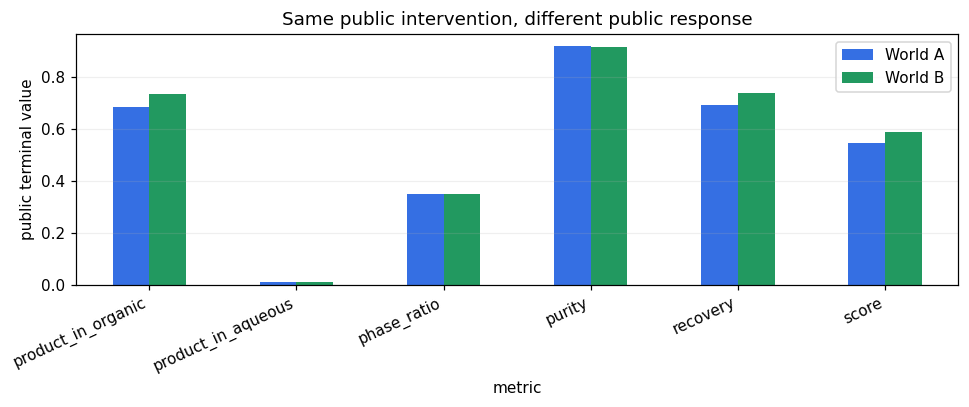

In [5]:
parent_public = parent["checkpoints"]["terminal_assay"]["public_observation"]
child_public = child["checkpoints"]["terminal_assay"]["public_observation"]
metrics = ["product_in_organic", "product_in_aqueous", "phase_ratio", "purity", "recovery", "score"]
comparison = pd.DataFrame([
    {"metric": metric, "World A": parent_public.get(metric), "World B": child_public.get(metric)}
    for metric in metrics
])
comparison["signed change"] = comparison["World B"] - comparison["World A"]
display(comparison)

ax = comparison.set_index("metric")[["World A", "World B"]].plot(kind="bar", color=["#356fe3", "#229960"])
ax.set(title="Same public intervention, different public response", ylabel="public terminal value")
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 5. Ask a mechanism-level question

Free-form explanations are difficult to score reliably. A controlled study can instead ask the Agent to choose a registered directional statement after repeated experiments.


In [6]:
mechanism_check = {
    "evidence_available_to_agent": ["typed actions", "public instrument observations", "resource receipts"],
    "question": "Relative to World A, what direction best describes World B's product-in-organic response under the fixed intervention?",
    "choices": ["increases", "decreases", "no detectable change", "insufficient evidence"],
    "scoring_note": "Score the selected direction against the registered evaluator; do not expose the author-side component label.",
}
mechanism_check


{'evidence_available_to_agent': ['typed actions',
  'public instrument observations',
  'resource receipts'],
 'question': "Relative to World A, what direction best describes World B's product-in-organic response under the fixed intervention?",
 'choices': ['increases',
  'decreases',
  'no detectable change',
  'insufficient evidence'],
 'scoring_note': 'Score the selected direction against the registered evaluator; do not expose the author-side component label.'}